# Free-Space Fresnel Propagation

This tutorial uses dLux's `FreeSpace` layer to model near-field diffraction with the angular spectrum method (ASM). Unlike focal-plane propagation, ASM retains a physically sampled transverse grid while propagating the complex wavefront through a finite distance.

In [1]:
import equinox as eqx
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu

from numpy import loadtxt
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 100

## Diffraction grating

We begin with a small crossed-slit grating. The aperture is generated on an oversampled grid and then averaged onto the wavefront sampling to retain partially illuminated edge pixels.

In [2]:
diameter = 1.2e-3
wf_npix = 128
oversample = 8

coordinates = dlu.pixel_coords(wf_npix * oversample, diameter)
centres = np.linspace(-diameter / 3, diameter / 3, 4)

slits = []
for centre in centres:
    local = coordinates - np.array([centre, 0.0])[:, None, None]
    slit = dlu.rectangle(local, width=diameter / 20, height=diameter)
    slits.extend((slit, slit.T))

grating = np.clip(np.stack(slits).sum(0), 0, 1)
grating = dlu.downsample(grating, oversample, mean=True)

## Free-space optical system

`ResizeSpec(pad=20, crop=2)` first zero-pads the field to suppress periodic wrap-around, then crops the propagated result to ten times the original field of view. The rendered images are downsampled afterwards to control memory without changing their physical extent.

In [3]:
pupil_spec = dl.GridSpec(n=(wf_npix,) * 2, diam=diameter, unit="m")
layers = [
    ("grating", dl.Optic(grating, normalise=True)),
    ("free_space", dl.FreeSpace(1.0, dl.ResizeSpec(pad=20, crop=2))),
]
optics = dl.OpticalSystem(layers, pupil_spec)

# Visible wavelengths with pre-normalised spectral weights
wavelengths = 1e-9 * np.linspace(380, 780, 30)
weights = np.linspace(1.0, 0.3, wavelengths.size)

# Propagate one wavelength at a time and downsample only the rendered intensity
render_downsample = 4

@eqx.filter_jit
def propagate_mono(distance, wavelength, weight):
    system = optics.set("free_space.distance", distance)
    psf = weight * system.propagate_mono(wavelength)
    return dlu.downsample(psf, render_downsample, mean=True)

def propagate_spectrum(distance):
    return np.stack([
        propagate_mono(distance, wavelength, weight)
        for wavelength, weight in zip(wavelengths, weights)
    ])

spectral_psfs = propagate_spectrum(1.0)
print(optics)
print("Spectral PSFs:", spectral_psfs.shape)

OpticalSystem(
  layers={
    'grating':
    Optic(opd=None, phase=None, transmission=f32[128,128], normalise=True),
    'free_space':
    FreeSpace(
      spec=ResizeSpec(n=None, pad=(20, 20), crop=(2, 2), c=None),
      distance=f32[],
      crop=True
    )
  },
  spec=GridSpec(n=(128, 128), d=f32[2], c=None, unit='m')
)
Spectral PSFs: (30, 320, 320)


## Spectral colour rendering

The following helper maps the wavelength-resolved intensities through the CIE colour-matching functions and converts XYZ colour into sRGB. It is adapted from [diffractsim](https://github.com/rafael-fuente/diffractsim).

In [4]:
## COLLAPSE: RGB conversion function
def rgb_from_psfs(psfs, wavelengths, gamma=True):
    """Convert wavelength-resolved intensity images into an sRGB image."""
    psfs = np.asarray(psfs, dtype=float)
    wavelengths = 1e9 * np.asarray(wavelengths, dtype=float)
    if psfs.shape[0] != wavelengths.size:
        raise ValueError("The leading PSF axis must match wavelengths.")

    cmf = loadtxt("files/cie-cmf.txt")
    matching = np.stack([
        np.interp(wavelengths, cmf[:, 0], cmf[:, i], left=0.0, right=0.0)
        for i in range(1, 4)
    ])
    scale = np.gradient(wavelengths) * 0.003975 * 683.002
    xyz = np.einsum("lyx,cl,l->cyx", psfs, matching, scale)

    transform = np.array([
        [3.2406, -1.5372, -0.4986],
        [-0.9689, 1.8758, 0.0415],
        [0.0557, -0.2040, 1.0570],
    ])
    rgb = np.einsum("ij,jyx->iyx", transform, xyz)

    low, high = rgb.min(0), rgb.max(0)
    scale = np.where(high > 0, high / (high - low + 1e-5), 1.0)
    rgb = np.where(low[None] < 0, scale[None] * (rgb - low[None]), rgb)
    if gamma:
        rgb = np.where(
            rgb <= 0.00304,
            12.92 * rgb,
            1.055 * np.maximum(rgb, 0) ** (1 / 2.4) - 0.055,
        )
        high = rgb.max(0) + 1e-5
        rgb = np.where(high[None] > 1, rgb / high[None], rgb)
    return np.clip(np.moveaxis(rgb, 0, -1), 0, 1)

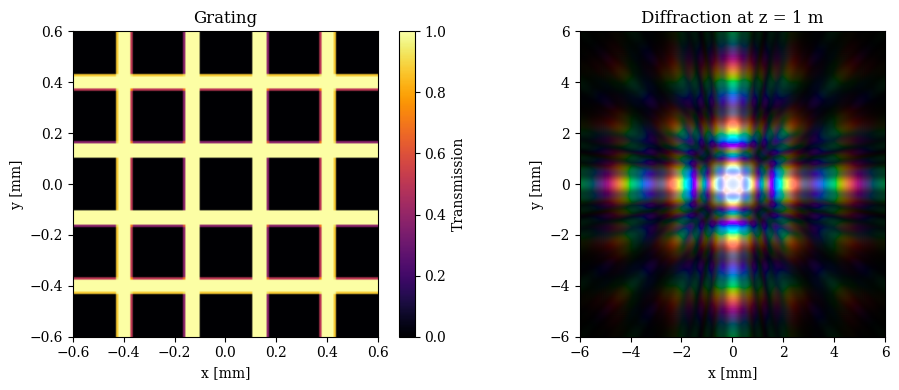

In [5]:
## COLLAPSE: Plotting code
rgb = rgb_from_psfs(500 * spectral_psfs, wavelengths)
resize = optics.free_space.spec
output_spec = pupil_spec.resize(resize.output_size(grating.shape))
output_spec = output_spec.downsample(render_downsample)
pupil_extent = 1e3 * pupil_spec.extent
output_extent = 1e3 * output_spec.extent

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
image = axes[0].imshow(grating, extent=pupil_extent)
plt.colorbar(image, ax=axes[0], label="Transmission")
axes[0].set(title="Grating", xlabel="x [mm]", ylabel="y [mm]")
axes[1].imshow(rgb, extent=output_extent)
axes[1].set(title="Diffraction at z = 1 m", xlabel="x [mm]", ylabel="y [mm]")
plt.tight_layout()
plt.show()

## Propagation through multiple planes

The propagation distance is an ordinary array leaf, so one compiled function can be reused for every plane. We calculate a modest set of frames directly in memory; no multi-gigabyte cache is required.

In [6]:
distances = np.linspace(0.01, 1.0, 18)
rgb_frames = []
for distance in tqdm(distances):
    frame = propagate_spectrum(distance)
    rgb_frames.append(rgb_from_psfs(500 * frame, wavelengths))

print("RGB frames:", len(rgb_frames), rgb_frames[0].shape)

  0%|          | 0/18 [00:00<?, ?it/s]

RGB frames: 18 (320, 320, 3)


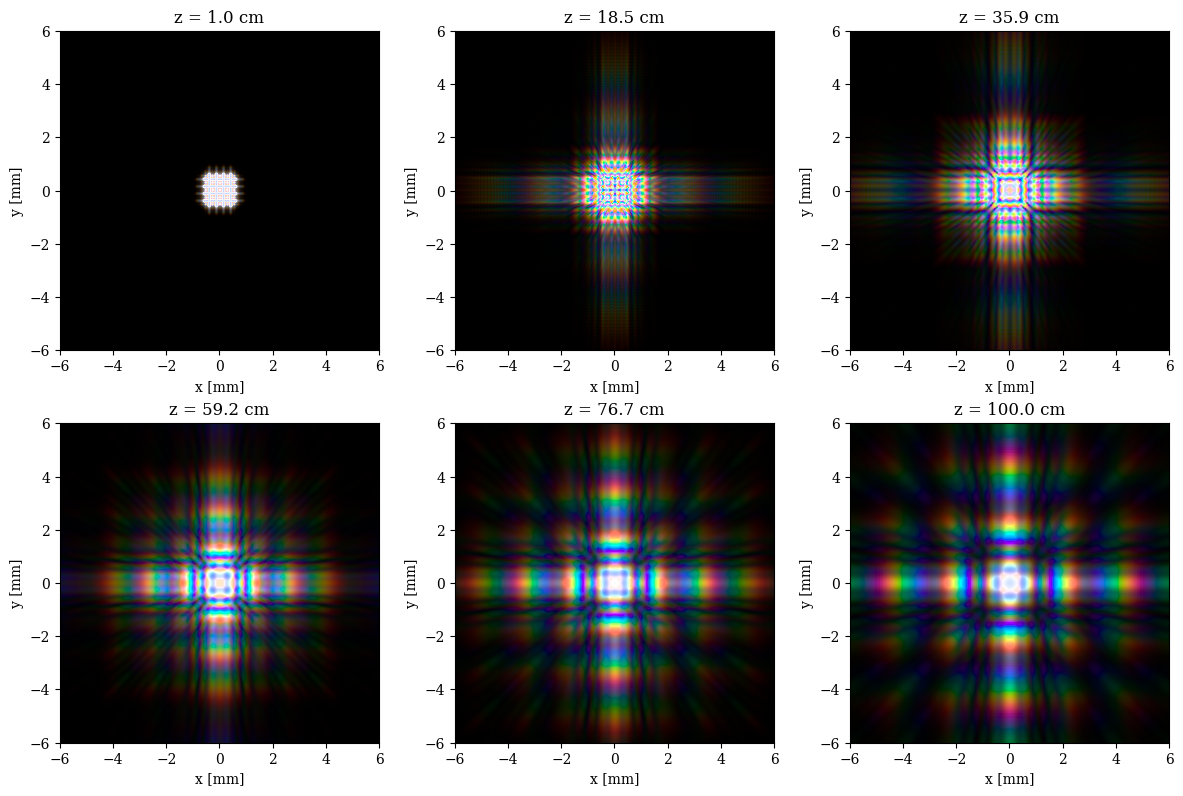

In [7]:
## COLLAPSE: Plotting code
indices = np.linspace(0, len(distances) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, index in zip(axes.flat, indices):
    ax.imshow(rgb_frames[index], extent=output_extent)
    ax.set_title(f"z = {100 * distances[index]:.1f} cm")
    ax.set(xlabel="x [mm]", ylabel="y [mm]")
plt.tight_layout()
plt.show()

The same frames can be viewed as an inline animation. Saving the animation is left as an explicit user action because it requires a local movie writer such as FFmpeg.

In [8]:
## COLLAPSE: Animation code
fig, ax = plt.subplots(figsize=(5, 5), dpi=80)
image = ax.imshow(rgb_frames[0], extent=output_extent)
title = ax.set_title(f"z = {100 * distances[0]:.1f} cm")
ax.set(xlabel="x [mm]", ylabel="y [mm]")

def update(index):
    image.set_data(rgb_frames[index])
    title.set_text(f"z = {100 * distances[index]:.1f} cm")
    return image, title

movie = animation.FuncAnimation(
    fig, update, frames=len(rgb_frames), interval=150, blit=False
)
plt.close(fig)
HTML(movie.to_jshtml())